In [8]:
import pandas as pd


# LOAD DATASET

df = pd.read_csv("Event_Booking_Details.csv")

# BASIC EDA

print(df.head())


print(df.tail())


print(df.shape)


print(df.columns)


print(df.dtypes)




print(df.isnull().sum())


print(df.duplicated().sum())

# DATA CLEANING


# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing values in numeric columns
num_cols = df.select_dtypes(include=["number"]).columns

for col in num_cols:
    df[col] = df[col].fillna(0)

# Fill missing values in text columns
text_cols = df.select_dtypes(include=["object", "string"]).columns

for col in text_cols:
    df[col] = df[col].fillna("Unknown")

# DATE CONVERSION


df["Created Date"] = pd.to_datetime(
    df["Created Date"],
    errors="coerce"
)


# DERIVED FEATURES

df["Month"] = df["Created Date"].dt.month

df["Year"] = df["Created Date"].dt.year

df["Revenue Per Ticket"] = (
    df["Grand Total"] / df["Ticket Count"]
)

df["Net Revenue"] = (
    df["Grand Total"] - df["Refund Amount"]
)

# Handle division by zero
df["Revenue Per Ticket"] = (
    df["Revenue Per Ticket"]
    .replace([float("inf"), -float("inf")], 0)
    .fillna(0)
)


# FINAL CHECKS


print("\n MISSING VALUES AFTER CLEANING ")
print(df.isnull().sum())

print("\n FINAL SHAPE ")
print(df.shape)

print("\n FINAL DATA TYPES ")
print(df.dtypes)


# DATA DICTIONARY
print("DATA DICTIONARY")
dictionary_df = pd.DataFrame({
    "Column": [
        "Booking No",
        "Ticket Count",
        "Ticket Amount",
        "Grand Total",
        "Processing Fee",
        "Platform Fee",
        "Event Name",
        "Organizer",
        "Payment Status",
        "Booking Status",
        "Stripe Revenue",
        "Eventox Revenue",
        "Organizer Revenue",
        "Refund Amount",
        "Created Date",
        "Month",
        "Year",
        "Revenue Per Ticket",
        "Net Revenue"
    ],
    "Description": [
        "Unique booking ID",
        "Number of tickets booked",
        "Amount of ticket purchased",
        "Total amount paid",
        "Payment processing fee",
        "Eventox platform fee",
        "Name of the event",
        "Event organizer",
        "Payment status",
        "Booking status",
        "Revenue from Stripe",
        "Revenue earned by Eventox",
        "Revenue earned by organizer",
        "Amount refunded",
        "Booking creation date",
        "Month extracted from Created Date",
        "Year extracted from Created Date",
        "Grand Total divided by Ticket Count",
        "Grand Total minus Refund Amount"
    ]
})


print(dictionary_df)


# SAVE OUTPUT FILES


# Save cleaned dataset
df.to_csv("Event_Booking_Details_cleaned.csv", index=False)

# Save data dictionary
dictionary_df.to_csv("data_dictionary.csv", index=False)
print("-------------------------------------------------------------------")

print("DATA CLEANING COMPLETED SUCCESSFULLY")

print("Cleaned Dataset Saved As : Event_Booking_Details_cleaned.csv")
print("Data Dictionary Saved As : data_dictionary.csv")

              Booking No   Ticket Type  Ticket Count  Ticket Amount  \
0  EV1748739848135F6K005       Student             1           30.0   
1  EV1748758580099VGME5F        Adults             3          111.0   
2  EV1748763708930R7SJLB        Adults             1           37.0   
3  EV1748771174918ZLCXRL  Couple Entry             2           68.0   
4  EV17487734560106AU1PF        Adults             4          120.0   

   Processing Fee  Ticket Fee  Platform Fee  Agent Fee  Discount Amount  \
0            0.75         0.5             0          0              0.0   
1            2.78         1.5             0          0              0.0   
2            0.93         0.5             0          0              0.0   
3            1.70         1.0             0          0              0.0   
4            3.00         2.0             0          0              0.0   

   Grand Total  ... Booking Status  \
0        31.25  ...      confirmed   
1       115.28  ...      confirmed   
2       

In [ ]:
pip install scikit-learn


========== MODEL PERFORMANCE ==========
MAE : 1.15
R2 Score : 0.03

========== NEXT 7 DAYS FORECAST ==========
Day 1: 3 Tickets
Day 2: 3 Tickets
Day 3: 3 Tickets
Day 4: 3 Tickets
Day 5: 3 Tickets
Day 6: 3 Tickets
Day 7: 3 Tickets

========== SUMMARY ==========
Total Expected Bookings : 21
Expected Revenue : ₹ 1917.08


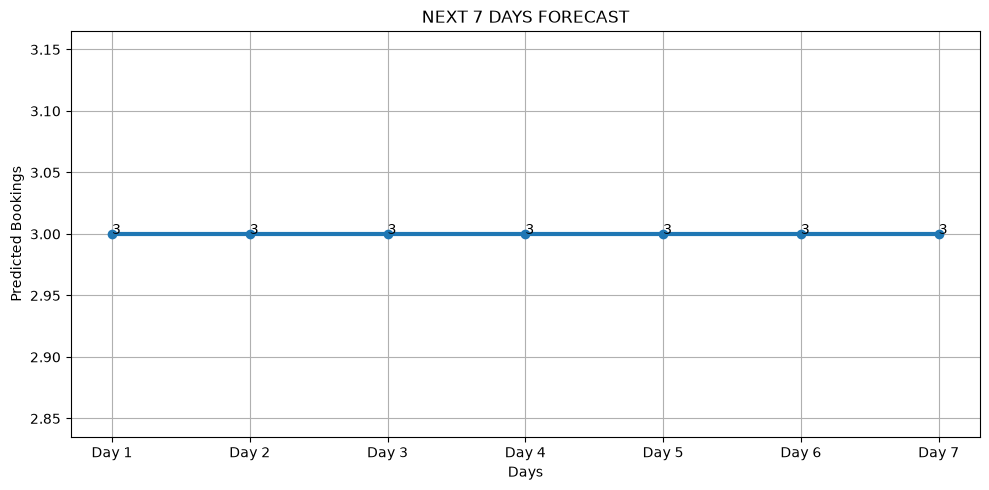

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# LOAD DATASET
df = pd.read_csv("Event_Booking_Details_cleaned.csv")

# DATA CLEANING
df["Created Date"] = pd.to_datetime(df["Created Date"], errors="coerce")
df["Ticket Count"] = pd.to_numeric(df["Ticket Count"], errors="coerce")
df["Ticket Amount"] = pd.to_numeric(df["Ticket Amount"], errors="coerce")

df = df.dropna(subset=["Created Date"])

df["Ticket Count"] = df["Ticket Count"].fillna(
    df["Ticket Count"].median()
)

df["Ticket Amount"] = df["Ticket Amount"].fillna(
    df["Ticket Amount"].median()
)

# FEATURE ENGINEERING
df["Month"] = df["Created Date"].dt.month
df["Weekday"] = df["Created Date"].dt.dayofweek
df["Day"] = df["Created Date"].dt.day

df["Sales_Velocity"] = (
    df["Ticket Count"]
    .rolling(window=7, min_periods=1)
    .mean()
)

# FEATURES & TARGET
X = df[
    [
        "Month",
        "Weekday",
        "Day",
        "Sales_Velocity"
    ]
]

y = df["Ticket Count"]

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# MODEL
model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

# EVALUATION
predictions = model.predict(X_test)

print("\n========== MODEL PERFORMANCE ==========")
print(
    "MAE :",
    round(mean_absolute_error(y_test, predictions), 2)
)

print(
    "R2 Score :",
    round(r2_score(y_test, predictions), 2)
)

# NEXT 7 DAYS FORECAST
current_month = int(df["Month"].iloc[-1])
current_day = int(df["Day"].iloc[-1])

latest_velocity = float(
    df["Sales_Velocity"].iloc[-1]
)

future_data = pd.DataFrame({
    "Month": [current_month] * 7,
    "Weekday": [0, 1, 2, 3, 4, 5, 6],
    "Day": [current_day + i for i in range(1, 8)],
    "Sales_Velocity": [latest_velocity] * 7
})

future_predictions = model.predict(future_data)

days = []
tickets = []

total_tickets = 0

print("\n========== NEXT 7 DAYS FORECAST ==========")

for i, pred in enumerate(future_predictions, start=1):

    booking = int(round(max(0, pred)))

    days.append(f"Day {i}")
    tickets.append(booking)

    total_tickets += booking

    print(f"Day {i}: {booking} Tickets")

# REVENUE FORECAST
avg_ticket_price = df["Ticket Amount"].mean()

expected_revenue = (
    total_tickets *
    avg_ticket_price
)

print("\n========== SUMMARY ==========")
print("Total Expected Bookings :", total_tickets)
print("Expected Revenue : ₹", round(expected_revenue, 2))

# ONLY GRAPH - NEXT 7 DAYS FORECAST

plt.figure(figsize=(10, 5))

plt.plot(
    days,
    tickets,
    marker="o",
    linewidth=3
)

plt.title("NEXT 7 DAYS FORECAST")
plt.xlabel("Days")
plt.ylabel("Predicted Bookings")

plt.grid(True)

for i, value in enumerate(tickets):
    plt.text(i, value, str(value))

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("Event_Booking_Details_cleaned.csv")

columns = [
    "Ticket Count",
    "Ticket Amount",
    "Platform Fee",
    "Processing Fee"
]

for col in columns:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

df = df.fillna(0)

median_tickets = df["Ticket Count"].median()

df["Success"] = (
    df["Ticket Count"] > median_tickets
).astype(int)

X = df[
    [
        "Ticket Amount",
        "Platform Fee",
        "Processing Fee"
    ]
]

y = df["Success"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

predictions = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    predictions
)

print("\nMODEL PERFORMANCE")
print(
    "Accuracy :",
    round(
        accuracy * 100,
        2
    ),
    "%"
)

sample = X_test.iloc[[0]]

prediction = model.predict(
    sample
)[0]

success_probability = (
    model.predict_proba(sample)[0][1]
    * 100
)

print("\nEVENT SUCCESS PREDICTION")

if prediction == 1:
    print(
        "Prediction : SUCCESSFUL EVENT"
    )
else:
    print(
        "Prediction : NOT SUCCESSFUL EVENT"
    )

print(
    "Success Probability :",
    round(
        success_probability,
        2
    ),
    "%"
)


MODEL PERFORMANCE
Accuracy : 88.37 %

EVENT SUCCESS PREDICTION
Prediction : SUCCESSFUL EVENT
Success Probability : 72.59 %


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report


# LOAD DATASET


df = pd.read_csv("Event_Booking_Details_cleaned.csv")


# DATE CONVERSION


df["Created Date"] = pd.to_datetime(
    df["Created Date"],
    errors="coerce"
)

df["Booking_Month"] = df["Created Date"].dt.month


# TARGET VARIABLE


df["Cancelled"] = (
    df["Booking Status"]
    .astype(str)
    .str.lower()
    .str.strip()
    .isin(["cancelled", "canceled"])
    .astype(int)
)


# EVENT TYPE ENCODING


le = LabelEncoder()

df["Event_Type"] = le.fit_transform(
    df["Event Name"].astype(str)
)


# PAST REFUND FEATURE


df["Past_Refund"] = (
    pd.to_numeric(
        df["Refund Amount"],
        errors="coerce"
    )
    .fillna(0)
    .gt(0)
    .astype(int)
)


# HANDLE MISSING VALUES


numeric_cols = [
    "Ticket Count",
    "Ticket Amount",
    "Booking_Month"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )
    df[col] = df[col].fillna(
        df[col].median()
    )

# FEATURES


X = df[
    [
        "Ticket Count",
        "Ticket Amount",
        "Booking_Month",
        "Event_Type",
        "Past_Refund"
    ]
]

y = df["Cancelled"]

X = X.fillna(0)


# TRAIN TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# RANDOM FOREST MODEL


model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)


# EVALUATION


predictions = model.predict(X_test)

accuracy = accuracy_score(
    y_test,
    predictions
)

print("\n MODEL PERFORMANCE ")
print("Accuracy :", round(accuracy * 100, 2), "%")

print("\nClassification Report")
print(
    classification_report(
        y_test,
        predictions,
        zero_division=0
    )
)


# SAMPLE PREDICTION


new_booking = pd.DataFrame({
    "Ticket Count": [2],
    "Ticket Amount": [500],
    "Booking_Month": [6],
    "Event_Type": [1],
    "Past_Refund": [0]
})

# Cancellation probability
risk_probability = (
    model.predict_proba(new_booking)[0][1]
)

print("\n CANCELLATION PREDICTION ")

print(
    "Cancellation Risk Score :",
    round(risk_probability, 4)
)

print(
    "Cancellation Risk Percentage :",
    round(risk_probability * 100, 2),
    "%"
)

if risk_probability >= 0.70:
    print("Risk Level : HIGH")
elif risk_probability >= 0.40:
    print("Risk Level : MEDIUM")
else:
    print("Risk Level : LOW")


 MODEL PERFORMANCE 
Accuracy : 87.07 %

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.88      0.93       823
           1       0.15      0.64      0.25        28

    accuracy                           0.87       851
   macro avg       0.57      0.76      0.59       851
weighted avg       0.96      0.87      0.91       851


 CANCELLATION PREDICTION 
Cancellation Risk Score : 0.4276
Cancellation Risk Percentage : 42.76 %
Risk Level : MEDIUM
